# Dataset Visualisation

This notebook visualises synthetic datasets through a small adapter layer. It shows source and target scatter plots for several covariate values, then shows latent ball level sets and, when the dataset exposes `push_u_given_x`, their oracle pushforwards. If no pushforward operator is available, the notebook falls back to target density contours when `log_prob` is implemented, otherwise target scatter plots.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
for candidate in [repo_root, *repo_root.parents]:
    if (candidate / "src").exists():
        repo_root = candidate
        break
else:
    raise RuntimeError("Could not find repository root containing src/.")

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from configs.datasets.synthetic import (
    BananaDatasetConfig,
    BimodalGaussianDatasetConfig,
    GaussianDatasetConfig,
    SinusoidalTransportDatasetConfig,
    StudentTDatasetConfig,
)
from data.datasets.synthetic import (
    BananaDataset,
    BimodalGaussianDataset,
    GaussianDatasetTarget,
    SinusoidalTransportDataset,
    StudentTDataset,
)

plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Choose Dataset

Swap `DatasetConfig` and `Dataset` here to inspect another synthetic dataset. The rest of the notebook adapts to the available methods on the dataset object.

In [2]:
seed = 7
torch.manual_seed(seed)
np.random.seed(seed)

device = "cpu"
dtype = "float32"

DatasetConfig = SinusoidalTransportDatasetConfig
Dataset = SinusoidalTransportDataset

dataset_config = DatasetConfig(
    n_train=6_000,
    n_calibration=1_000,
    n_test=1_000,
    seed=seed,
    device=device,
    dtype=dtype,
)
dataset = Dataset(dataset_config)

dataset_config

SinusoidalTransportDatasetConfig(type='sinusoidal_transport', n_train=6000, n_calibration=1000, n_test=1000, x_dim=1, y_dim=2, x_low=-1.0, x_high=1.0, amplitude=1.0, amplitude_x_scale=0.5, frequency=2.0, phase=0.0, vertical_scale=1.0, vertical_scale_x_scale=0.35, seed=7, device='cpu', dtype='float32')

In [3]:
def as_numpy(tensor):
    return tensor.detach().cpu().numpy()


def has_method(obj, name):
    return callable(getattr(obj, name, None))


def context_values(dataset, n_values=3):
    if dataset.x_dim == 0:
        return [None]

    config = getattr(dataset, "config", None)
    if hasattr(config, "x_low") and hasattr(config, "x_high"):
        return [float(v) for v in np.linspace(config.x_low, config.x_high, n_values)]

    splits = dataset.get_splits()
    values = as_numpy(splits.train.x[:, 0])
    if values.size == 0:
        return [0.0]

    return [float(v) for v in np.quantile(values, np.linspace(0.1, 0.9, n_values))]


def make_context(value, n):
    x = torch.zeros(
        n,
        dataset.x_dim,
        device=dataset.device,
        dtype=dataset.dtype,
    )
    if value is not None and dataset.x_dim > 0:
        x[:, 0] = float(value)
    return x


def context_label(value):
    if value is None:
        return "unconditional"
    return f"x1 = {value:.2f}"


def sample_latent(n):
    if has_method(dataset, "sample_source"):
        return dataset.sample_source(n)

    return torch.randn(
        n,
        dataset.y_dim,
        device=dataset.device,
        dtype=dataset.dtype,
    )


def sample_target_at_context(x, u=None):
    if u is not None and has_method(dataset, "push_u_given_x"):
        return dataset.push_u_given_x(u=u, x=x)

    return dataset.sample_conditional(x=x, n_samples=1).squeeze(1)


def circle_boundary(radius, n_points=720):
    theta = torch.linspace(
        0.0,
        2.0 * torch.pi,
        n_points + 1,
        device=dataset.device,
        dtype=dataset.dtype,
    )
    return radius * torch.stack([torch.cos(theta), torch.sin(theta)], dim=-1)


def set_equal_2d(ax):
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.18, linewidth=0.6)


def padded_bounds(points, margin=0.08):
    points = np.asarray(points)
    lower = points.min(axis=0)
    upper = points.max(axis=0)
    span = np.maximum(upper - lower, 1e-6)
    return lower - margin * span, upper + margin * span


def try_log_prob(x, y):
    if not has_method(dataset, "log_prob"):
        return None
    try:
        return dataset.log_prob(x=x, y=y)
    except NotImplementedError:
        return None


if dataset.y_dim != 2:
    raise ValueError("This visualisation notebook expects y_dim = 2.")

In [4]:
splits = dataset.get_splits()

operator_summary = {
    "push_u_given_x": has_method(dataset, "push_u_given_x"),
    "push_y_given_x": has_method(dataset, "push_y_given_x"),
    "sample_source": has_method(dataset, "sample_source"),
    "log_prob": try_log_prob(splits.train.x[:2], splits.train.y[:2]) is not None,
}

print(type(dataset).__name__)
print("train:", tuple(splits.train.x.shape), tuple(splits.train.y.shape))
print("calibration:", tuple(splits.calibration.x.shape), tuple(splits.calibration.y.shape))
print("test:", tuple(splits.test.x.shape), tuple(splits.test.y.shape))
print("operators:", operator_summary)

covariate_values = context_values(dataset, n_values=3)
covariate_values

SinusoidalTransportDataset
train: (6000, 1) (6000, 2)
calibration: (1000, 1) (1000, 2)
test: (1000, 1) (1000, 2)
operators: {'push_u_given_x': True, 'push_y_given_x': True, 'sample_source': True, 'log_prob': True}


[-1.0, 0.0, 1.0]

## Source And Target Scatters

The left column is latent/source samples. The right column is the corresponding target sample at a fixed covariate value. If the dataset has `push_u_given_x`, the same source points are pushed forward; otherwise the target points are sampled from `sample_conditional`.

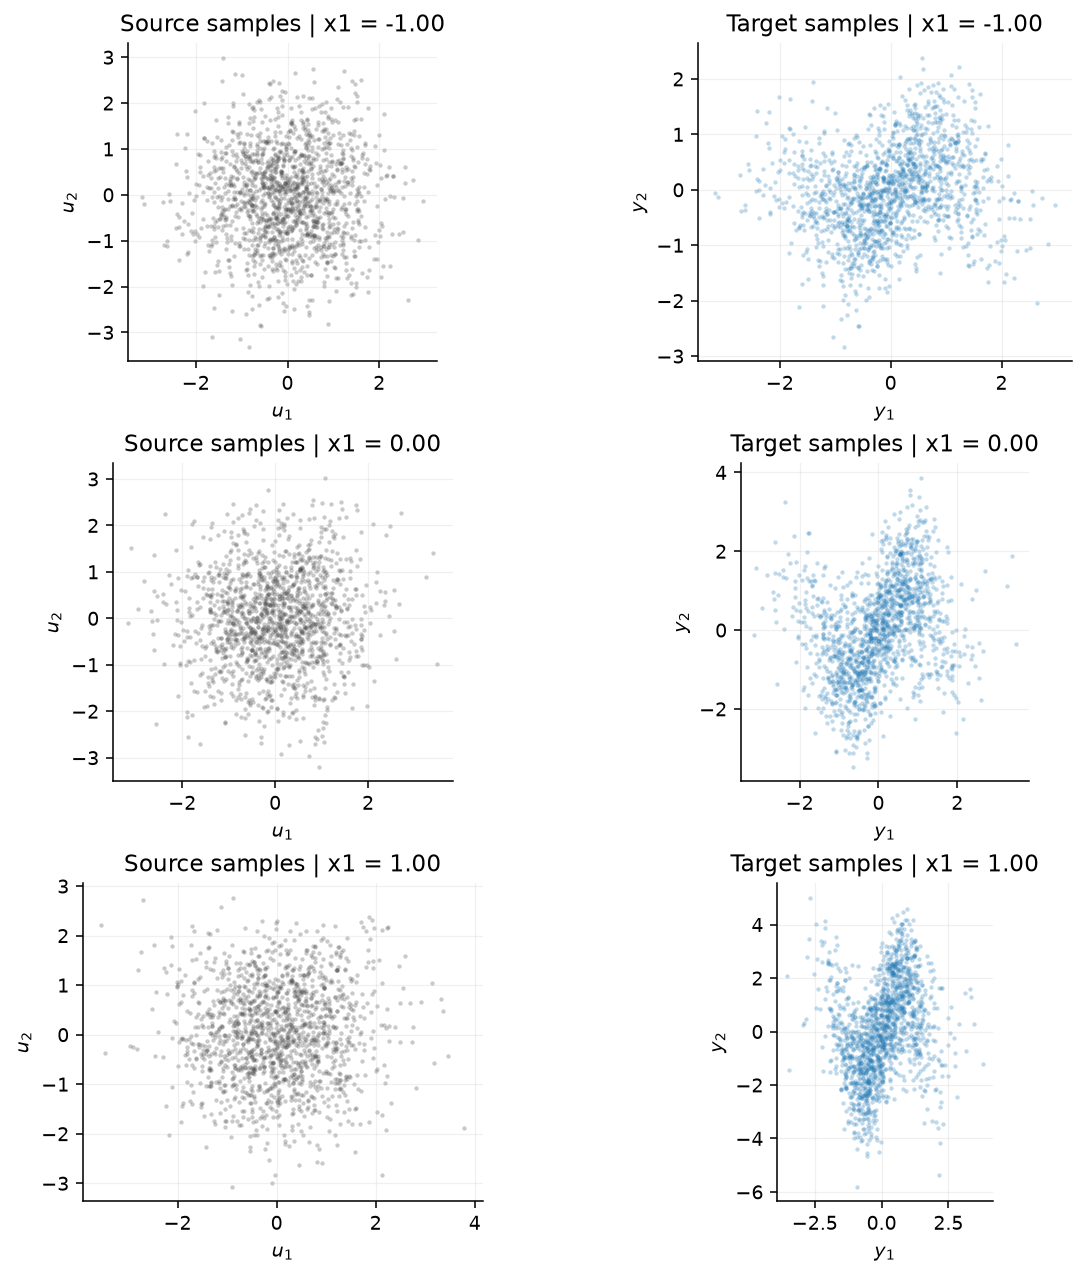

In [5]:
n_scatter = 1_500

fig, axes = plt.subplots(
    len(covariate_values),
    2,
    figsize=(8.6, 3.0 * len(covariate_values)),
    squeeze=False,
    constrained_layout=True,
)

for row, value in enumerate(covariate_values):
    x = make_context(value, n_scatter)
    u = sample_latent(n_scatter)
    y = sample_target_at_context(x=x, u=u)

    u_np = as_numpy(u)
    y_np = as_numpy(y)

    ax_source, ax_target = axes[row]
    ax_source.scatter(u_np[:, 0], u_np[:, 1], s=5, alpha=0.28, color="0.25", linewidths=0)
    ax_source.set_title(f"Source samples | {context_label(value)}")
    ax_source.set_xlabel(r"$u_1$")
    ax_source.set_ylabel(r"$u_2$")
    set_equal_2d(ax_source)

    ax_target.scatter(y_np[:, 0], y_np[:, 1], s=5, alpha=0.28, color="tab:blue", linewidths=0)
    ax_target.set_title(f"Target samples | {context_label(value)}")
    ax_target.set_xlabel(r"$y_1$")
    ax_target.set_ylabel(r"$y_2$")
    set_equal_2d(ax_target)

plt.show()

## Ball Level Sets

The left column shows latent ball boundaries. The right column shows their pushforwards when the dataset has `push_u_given_x`. Without that operator, the notebook shows target density contours if `log_prob` is available, otherwise target scatter.

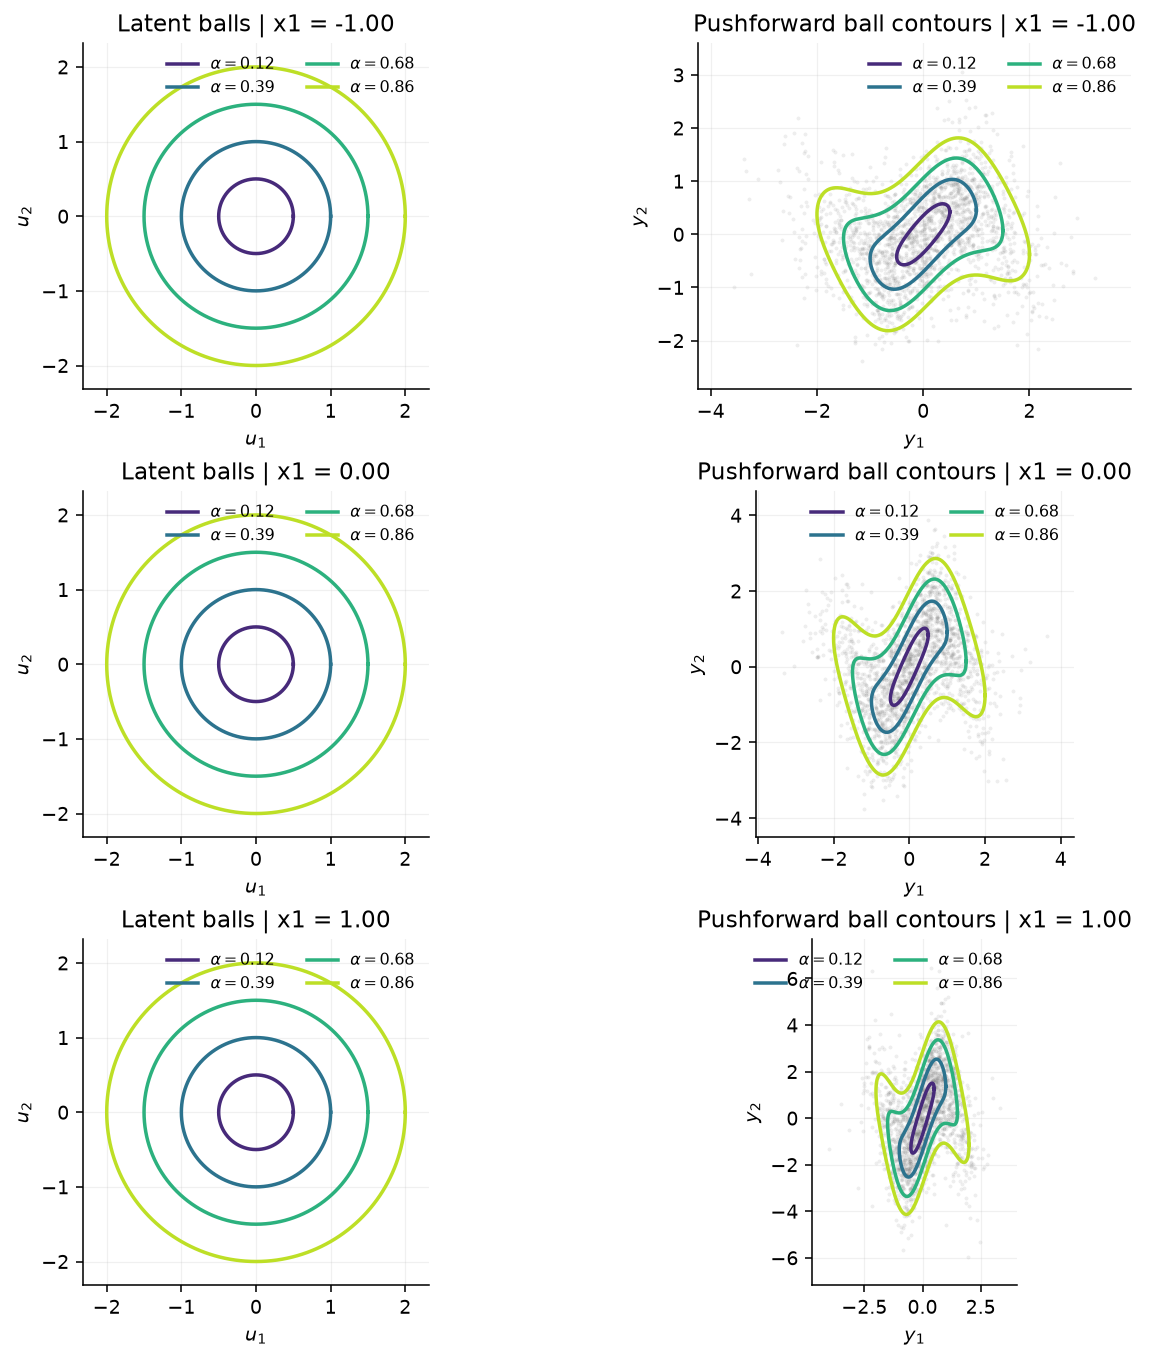

In [6]:
ball_radii = [0.5, 1.0, 1.5, 2.0]
n_boundary_points = 720
n_backdrop = 2_000
ball_coverages = [1.0 - np.exp(-0.5 * radius**2) for radius in ball_radii]
colors = plt.cm.viridis(np.linspace(0.12, 0.9, len(ball_radii)))

fig, axes = plt.subplots(
    len(covariate_values),
    2,
    figsize=(9.4, 3.2 * len(covariate_values)),
    squeeze=False,
    constrained_layout=True,
)

for row, value in enumerate(covariate_values):
    ax_source, ax_target = axes[row]

    source_contours = []
    target_contours = []
    for radius, coverage, color in zip(ball_radii, ball_coverages, colors):
        label = rf"$\alpha={coverage:.2f}$"
        u_boundary = circle_boundary(radius=radius, n_points=n_boundary_points)
        u_np = as_numpy(u_boundary)
        source_contours.append(u_np)
        ax_source.plot(u_np[:, 0], u_np[:, 1], color=color, linewidth=1.8, label=label)

        if has_method(dataset, "push_u_given_x"):
            x_boundary = make_context(value, u_boundary.shape[0])
            y_boundary = dataset.push_u_given_x(u=u_boundary, x=x_boundary)
            y_np = as_numpy(y_boundary)
            target_contours.append(y_np)
            ax_target.plot(y_np[:, 0], y_np[:, 1], color=color, linewidth=1.8, label=label)

    source_points = np.vstack(source_contours)
    source_lower, source_upper = padded_bounds(source_points)
    ax_source.set_xlim(source_lower[0], source_upper[0])
    ax_source.set_ylim(source_lower[1], source_upper[1])
    ax_source.set_title(f"Latent balls | {context_label(value)}")
    ax_source.set_xlabel(r"$u_1$")
    ax_source.set_ylabel(r"$u_2$")
    ax_source.legend(frameon=False, ncol=2, fontsize=8)
    set_equal_2d(ax_source)

    x_backdrop = make_context(value, n_backdrop)
    u_backdrop = sample_latent(n_backdrop)
    y_backdrop = sample_target_at_context(x=x_backdrop, u=u_backdrop)
    y_backdrop_np = as_numpy(y_backdrop)
    ax_target.scatter(y_backdrop_np[:, 0], y_backdrop_np[:, 1], s=4, alpha=0.10, color="0.35", linewidths=0)

    if target_contours:
        target_points = np.vstack([y_backdrop_np, *target_contours])
        title = f"Pushforward ball contours | {context_label(value)}"
    else:
        target_points = y_backdrop_np
        lower, upper = padded_bounds(target_points, margin=0.12)
        xx, yy = np.meshgrid(
            np.linspace(lower[0], upper[0], 140),
            np.linspace(lower[1], upper[1], 140),
        )
        grid_y = torch.as_tensor(
            np.column_stack([xx.ravel(), yy.ravel()]),
            device=dataset.device,
            dtype=dataset.dtype,
        )
        grid_x = make_context(value, grid_y.shape[0])
        log_prob = try_log_prob(grid_x, grid_y)
        if log_prob is not None:
            zz = as_numpy(log_prob).reshape(xx.shape)
            levels = np.quantile(zz[np.isfinite(zz)], [0.55, 0.70, 0.82, 0.91])
            ax_target.contour(xx, yy, zz, levels=levels, colors="tab:orange", linewidths=1.2)
            title = f"Target density contours | {context_label(value)}"
        else:
            title = f"Target scatter only | {context_label(value)}"

    target_lower, target_upper = padded_bounds(target_points, margin=0.10)
    ax_target.set_xlim(target_lower[0], target_upper[0])
    ax_target.set_ylim(target_lower[1], target_upper[1])
    ax_target.set_title(title)
    ax_target.set_xlabel(r"$y_1$")
    ax_target.set_ylabel(r"$y_2$")
    set_equal_2d(ax_target)
    if target_contours:
        ax_target.legend(frameon=False, ncol=2, fontsize=8)

if not has_method(dataset, "push_u_given_x"):
    print("dataset.push_u_given_x is not available; target pushforward ball contours were replaced by the best available fallback.")

plt.show()